# Predicting Patients Requiring Proactive Post-Discharge Follow-Up

## Business Problem
Hospital operations and care coordination teams need to decide **which discharged patients should receive proactive follow-up** (calls, home visits, early appointments).

Resources are limited — not every patient can receive intensive follow-up.

## Objective
Identify patients at high risk of **long hospital stay**, so care teams can prioritize post-discharge intervention and reduce downstream complications.

## Stakeholder
Hospital operations & care coordination teams

## Key Risk
Missing a high-risk patient leads to patient harm, readmission penalties, and operational strain.


## Data Overview

This dataset contains patient demographics, admission details, diagnoses, lab results, medications, and outcomes from hospital encounters.
Each row represents a single hospital encounter.


In [4]:
import pandas as pd

df = pd.read_csv("diabetic_data.csv")

In [5]:
df.shape


(101766, 50)

In [6]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [7]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
df.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [9]:
df['time_in_hospital'].describe()

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64

In [10]:
df.isin(['?', 'Unknown', 'None']).sum().sort_values(ascending=False).head(10)

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
encounter_id             0
tolazamide               0
glyburide                0
dtype: int64

In [11]:
# Drop junk columns from df
df = df.drop(columns=['encounter_id', 'patient_nbr', 'readmitted', 'weight', 'medical_specialty', 'payer_code'])


In [12]:
df.isna().sum().sort_values(ascending=False)



max_glu_serum               96420
A1Cresult                   84748
race                            0
troglitazone                    0
glipizide                       0
glyburide                       0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
tolazamide                      0
glimepiride                     0
examide                         0
citoglipton                     0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
acetohexamide                   0
chlorpropamide                  0
gender                          0
nateglinide                     0
age                             0
admission_type_id               0
discharge_disposition_id        0
admission_sour

In [13]:
# Replace ? with NaN so pandas understands it's missing
df.replace('?', pd.NA, inplace=True)


In [14]:
df.isna().sum().sort_values(ascending=False).head(10)


max_glu_serum    96420
A1Cresult        84748
race              2273
diag_3            1423
diag_2             358
diag_1              21
glipizide            0
tolbutamide          0
pioglitazone         0
rosiglitazone        0
dtype: int64

In [15]:
df['max_glu_serum'] = df['max_glu_serum'].fillna('Not Tested')
df['A1Cresult'] = df['A1Cresult'].fillna('Not Tested')


In [16]:
df['A1Cresult'].value_counts(dropna=False)


A1Cresult
Not Tested    84748
>8             8216
Norm           4990
>7             3812
Name: count, dtype: int64

In [17]:
df['max_glu_serum'].value_counts(dropna=False)

max_glu_serum
Not Tested    96420
Norm           2597
>200           1485
>300           1264
Name: count, dtype: int64

In [18]:
df['race'] = df['race'].fillna('Unknown')


In [19]:
df['race'].value_counts(dropna=False)


race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

## Feature Engineering

Raw diagnosis codes and clinical signals are transformed into interpretable features that reflect:
- Overall disease burden
- Presence of injury-related conditions
- Primary clinical category driving admission

This improves interpretability and reduces noise.


In [21]:
def group_diagnosis(code):
    if pd.isna(code) or code == '?':
        return 'Unknown'

    code = str(code)

    # External causes
    if code.startswith('V') or code.startswith('E'):
        return 'Injury'

    try:
        code = float(code)
    except:
        return 'Other'

    if 1 <= code < 140:
        return 'Infectious'
    elif 140 <= code < 240:
        return 'Neoplasms'
    elif 240 <= code < 280:
        return 'Endocrine'
    elif 280 <= code < 290:
        return 'Blood'
    elif 290 <= code < 320:
        return 'Mental'
    elif 320 <= code < 390:
        return 'Neurological'
    elif 390 <= code < 460:
        return 'Circulatory'
    elif 460 <= code < 520:
         return 'Respiratory'
    elif 520 <= code < 580:
        return 'Digestive'
    elif 580 <= code < 630:
        return 'Genitourinary'
    elif 630 <= code < 680:
        return 'Pregnancy'
    elif 680 <= code < 710:
        return 'Skin'
    elif 710 <= code < 740:
        return 'Musculoskeletal'
    elif 740 <= code < 760:
        return 'Congenital'
    elif 760 <= code < 780:
        return 'Perinatal'
    elif 780 <= code < 800:
        return 'Symptoms'
    elif 800 <= code < 1000:
        return 'Injury'
    else:
        return 'Other'

In [22]:
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col + '_group'] = df[col].apply(group_diagnosis)


In [23]:
df['primary_diag_group'] = df['diag_1_group']

In [24]:
df['primary_diag_group'].head()

0     Endocrine
1     Endocrine
2     Pregnancy
3    Infectious
4     Neoplasms
Name: primary_diag_group, dtype: object

In [25]:
df[['diag_1_group', 'diag_2_group', 'diag_3_group']].head()


,diag_1_group,diag_2_group,diag_3_group
0,Endocrine,Unknown,Unknown
1,Endocrine,Endocrine,Endocrine
2,Pregnancy,Endocrine,Injury
3,Infectious,Endocrine,Circulatory
4,Neoplasms,Neoplasms,Endocrine


In [26]:
df['num_diagnosis'] = (
    df[['diag_1', 'diag_2', 'diag_3']]
    .notna()
    .sum(axis=1)
)


In [27]:
df['has_injury'] = (
    (df['diag_1_group'] == 'Injury') |
    (df['diag_2_group'] == 'Injury') |
    (df['diag_3_group'] == 'Injury')
).astype(int)


In [28]:
df[['primary_diag_group', 'num_diagnosis']].head()



,primary_diag_group,num_diagnosis
0,Endocrine,1
1,Endocrine,3
2,Pregnancy,3
3,Infectious,3
4,Neoplasms,3


In [29]:
df['num_diagnosis'].value_counts()

num_diagnosis
3    100244
2      1243
1       278
0         1
Name: count, dtype: int64

In [30]:
# drop the garbage rows first
df = df[df['num_diagnosis'] > 0]

In [31]:
df.groupby('num_diagnosis')['time_in_hospital'].mean()


num_diagnosis
1    2.611511
2    2.834272
3    4.420275
Name: time_in_hospital, dtype: float64

In [32]:
drop_cols = ['diag_1', 'diag_2', 'diag_3',
    'diag_1_group', 'diag_2_group', 'diag_3_group'
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])


In [33]:
y = df['time_in_hospital']
X = df.drop(columns=['time_in_hospital'])

In [34]:
# Norminal encoding
age_map = {
    '[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3,
    '[40-50)': 4, '[50-60)': 5, '[60-70)': 6,
    '[70-80)': 7, '[80-90)': 8, '[90-100)': 9
}

X['age'] = X['age'].map(age_map)


In [35]:
# Severity level
a1c_map = {
    'Not Tested': 0,
    'Norm': 0,
    '>7': 1,
    '>8': 2
}

glu_map = {
    'Not Tested': 0,
    'Norm': 0,
    '>200': 1,
    '>300': 2
}

X['A1Cresult'] = X['A1Cresult'].map(a1c_map)
X['max_glu_serum'] = X['max_glu_serum'].map(glu_map)


In [36]:
# Binary coding
binary_map = {'Yes': 1, 'No': 0, 'Ch': 1}

X['change'] = X['change'].map(binary_map)
X['diabetesMed'] = X['diabetesMed'].map(binary_map)


In [37]:
med_map = {
    'No': 0,
    'Steady': 1,
    'Up': 2,
    'Down': -1
}

med_cols = [
    'metformin','repaglinide','nateglinide','chlorpropamide',
    'glimepiride','acetohexamide','glipizide','glyburide',
    'tolbutamide','pioglitazone','rosiglitazone','acarbose',
    'miglitol','troglitazone','tolazamide','examide',
    'citoglipton','insulin','glyburide-metformin',
    'glipizide-metformin','glimepiride-pioglitazone',
    'metformin-rosiglitazone','metformin-pioglitazone'
]

for col in med_cols:
    X[col] = X[col].map(med_map)


## Feature Selection (Locked)

At this stage, features are finalized based on:
- Clinical relevance
- Availability at discharge
- Interpretability for operations teams

No features will be added beyond this point.


## Encoding & Preprocessing

Categorical variables are one-hot encoded.
Numerical variables are retained in their original scale.

The goal is model clarity and operational interpretability.


In [41]:
# One-hot encoding
categorical_cols = [
    'race',
    'gender',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'primary_diag_group'
]

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


In [42]:
X.isna().sum().sort_values(ascending=False).head(10)
X.dtypes.value_counts()


bool     71
int64    36
int32     1
Name: count, dtype: int64

In [43]:
X = X.astype(int)

## Train–Test Split

To evaluate whether the model generalizes beyond the data it was trained on,
the dataset was split into training (80%) and testing (20%) subsets.

The test set is held out and used only for final evaluation.

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [46]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((81412, 108), (20353, 108), (81412,), (20353,))

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [48]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 1.7880710284597336
RMSE: 2.3503214911053805
R²: 0.36513073627711035


C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [49]:
y_pred = model.predict(X_test)
residuals = y_test - y_pred


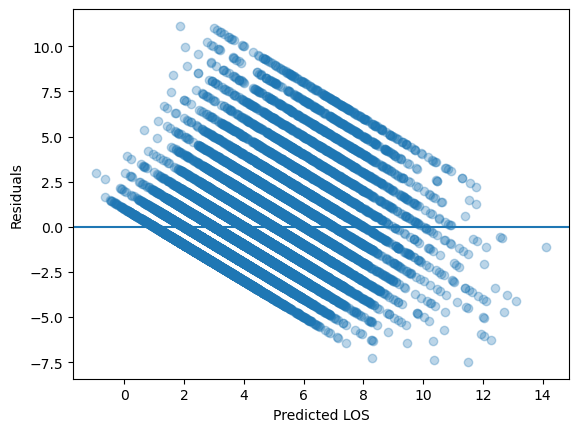

In [50]:
import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Predicted LOS")
plt.ylabel("Residuals")
plt.show()


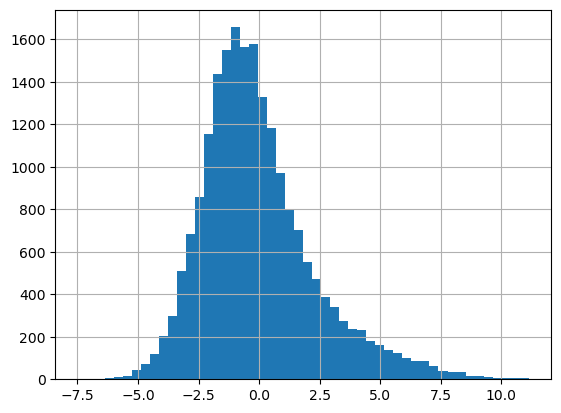

In [51]:
residuals.hist(bins=50)
plt.show()


In [52]:
pd.DataFrame({
    'true': y_test,
    'abs_error': abs(residuals)
}).groupby('true')['abs_error'].mean().head(10)


true
1     1.861646
2     1.562470
3     1.307588
4     1.156122
5     1.135425
6     1.362510
7     1.825741
8     2.339700
9     3.012303
10    3.670301
Name: abs_error, dtype: float64

## Baseline Risk Model

A logistic regression model is used as the baseline because:
- It is interpretable
- Coefficients translate directly to risk direction
- It aligns with clinical and operational decision-making

Class imbalance is handled explicitly to avoid underestimating high-risk patients.

In [54]:
y_class = (y >= 7).astype(int)


In [55]:
y_class.value_counts(normalize=True)


time_in_hospital
0    0.792188
1    0.207812
Name: proportion, dtype: float64

We reframe length of stay into a binary risk signal to support operational decisions.
The model’s goal is recall: identifying patients likely to have prolonged stays so that limited follow-up resources are allocated early.

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)


In [58]:
y_train.mean(), y_test.mean()


(0.20780720286935586, 0.20783176927234315)


## Model Evaluation

Evaluation focuses on:
- Recall for high-risk patients
- Precision trade-offs
- Confusion matrix analysis

Accuracy alone is not sufficient due to class imbalance.


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=3000,
    random_state=42
)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[12096  4027]
 [ 1098  3132]]
              precision    recall  f1-score   support

           0       0.92      0.75      0.83     16123
           1       0.44      0.74      0.55      4230

    accuracy                           0.75     20353
   macro avg       0.68      0.75      0.69     20353
weighted avg       0.82      0.75      0.77     20353



In [61]:
y_proba = lr.predict_proba(X_test)[:, 1]


## Decision Threshold Tuning

Instead of relying on a default 0.5 threshold, multiple thresholds are evaluated.

This allows the business to choose a balance between:
- Missing high-risk patients
- Operational workload from follow-ups


In [63]:
import numpy as np
from sklearn.metrics import recall_score, precision_score

thresholds = [0.5, 0.4, 0.3, 0.2]

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    cm = confusion_matrix(y_test, y_pred_t)
    
    print(f"\nThreshold: {t}")
    print("Recall:", round(recall, 3))
    print("Precision:", round(precision, 3))
    print("Confusion Matrix:\n", cm)



Threshold: 0.5
Recall: 0.74
Precision: 0.437
Confusion Matrix:
 [[12096  4027]
 [ 1098  3132]]

Threshold: 0.4
Recall: 0.837
Precision: 0.378
Confusion Matrix:
 [[10306  5817]
 [  690  3540]]

Threshold: 0.3
Recall: 0.909
Precision: 0.324
Confusion Matrix:
 [[8112 8011]
 [ 387 3843]]

Threshold: 0.2
Recall: 0.958
Precision: 0.274
Confusion Matrix:
 [[ 5374 10749]
 [  179  4051]]


In [64]:
threshold = 0.3
y_pred_final = (y_proba >= threshold).astype(int)


In [65]:

coeffs = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_[0]
}).sort_values(by="coefficient", ascending=False)

coeffs


,feature,coefficient
99,primary_diag_group_Mental,2.140341
90,admission_source_id_22,1.557677
64,discharge_disposition_id_15,1.435091
71,discharge_disposition_id_23,1.432120
57,discharge_disposition_id_8,1.312206
...,...,...
89,admission_source_id_20,-0.617754
18,tolbutamide,-0.718299
106,primary_diag_group_Symptoms,-0.720488
103,primary_diag_group_Pregnancy,-0.771329


In [66]:
coeffs["odds_ratio"] = coeffs["coefficient"].apply(lambda x: np.exp(x))
coeffs


,feature,coefficient,odds_ratio
99,primary_diag_group_Mental,2.140341,8.502334
90,admission_source_id_22,1.557677,4.747780
64,discharge_disposition_id_15,1.435091,4.200025
71,discharge_disposition_id_23,1.432120,4.187568
57,discharge_disposition_id_8,1.312206,3.714360
...,...,...,...
89,admission_source_id_20,-0.617754,0.539154
18,tolbutamide,-0.718299,0.487581
106,primary_diag_group_Symptoms,-0.720488,0.486515
103,primary_diag_group_Pregnancy,-0.771329,0.462398


In [67]:

coeffs[['feature', 'coefficient', 'odds_ratio']].tail(15)


,feature,coefficient,odds_ratio
88,admission_source_id_17,-0.280700,0.755255
61,discharge_disposition_id_12,-0.313590,0.730818
37,race_Asian,-0.333631,0.716318
38,race_Caucasian,-0.365045,0.694166
56,discharge_disposition_id_7,-0.369188,0.691295
22,miglitol,-0.392124,0.675620
41,race_Unknown,-0.454478,0.634780
68,discharge_disposition_id_19,-0.569280,0.565933
46,admission_type_id_4,-0.582028,0.558764
107,primary_diag_group_Unknown,-0.603863,0.546696


In [68]:
coeffs[['feature', 'coefficient', 'odds_ratio']].head(15)

,feature,coefficient,odds_ratio
99,primary_diag_group_Mental,2.140341,8.502334
90,admission_source_id_22,1.557677,4.747780
64,discharge_disposition_id_15,1.435091,4.200025
71,discharge_disposition_id_23,1.432120,4.187568
57,discharge_disposition_id_8,1.312206,3.714360
59,discharge_disposition_id_10,1.225372,3.405434
54,discharge_disposition_id_5,1.163478,3.201048
29,glipizide-metformin,1.019236,2.771077
74,discharge_disposition_id_27,1.018141,2.768043
67,discharge_disposition_id_18,1.009204,2.743416


In [69]:
top_risk = coeffs.head(10)
top_protective = coeffs.tail(10)


In [70]:
top_risk, top_protective


(                        feature  coefficient  odds_ratio
 99    primary_diag_group_Mental     2.140341    8.502334
 90       admission_source_id_22     1.557677    4.747780
 64  discharge_disposition_id_15     1.435091    4.200025
 71  discharge_disposition_id_23     1.432120    4.187568
 57   discharge_disposition_id_8     1.312206    3.714360
 59  discharge_disposition_id_10     1.225372    3.405434
 54   discharge_disposition_id_5     1.163478    3.201048
 29          glipizide-metformin     1.019236    2.771077
 74  discharge_disposition_id_27     1.018141    2.768043
 67  discharge_disposition_id_18     1.009204    2.743416,
                                 feature  coefficient  odds_ratio
 22                             miglitol    -0.392124    0.675620
 41                         race_Unknown    -0.454478    0.634780
 68          discharge_disposition_id_19    -0.569280    0.565933
 46                  admission_type_id_4    -0.582028    0.558764
 107          primary_diag_grou

## Decision Tree Analysis (Interpretability Check)

To validate the signals learned by the logistic regression model, a shallow decision tree was trained as an interpretability check.

The goal here is **not** to outperform logistic regression, but to:
- Confirm which features dominate early splits
- Check if clinical logic aligns with model behavior
- Identify obvious rule-based risk patterns


In [72]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=200,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       0.84      0.96      0.89     16123
           1       0.66      0.28      0.39      4230

    accuracy                           0.82     20353
   macro avg       0.75      0.62      0.64     20353
weighted avg       0.80      0.82      0.79     20353

[[15516   607]
 [ 3058  1172]]


### Model Behavior

The decision tree prioritizes a small subset of features at the top splits, indicating that risk is driven by a few dominant clinical signals rather than diffuse noise.

This aligns with the coefficient-based feature importance observed in the logistic regression model.


In [74]:
tree_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": dt.feature_importances_
}).sort_values(by="importance", ascending=False)

tree_importance.head(15)


,feature,importance
3,num_medications,0.683988
1,num_lab_procedures,0.176862
100,primary_diag_group_Musculoskeletal,0.038521
98,primary_diag_group_Injury,0.024671
52,discharge_disposition_id_3,0.023688
2,num_procedures,0.022624
99,primary_diag_group_Mental,0.017500
45,admission_type_id_3,0.009023
7,number_diagnoses,0.001344
55,discharge_disposition_id_6,0.001018


### Model Behavior

The decision tree prioritizes a small subset of features at the top splits, indicating that risk is driven by a few dominant clinical signals rather than diffuse noise.

This aligns with the coefficient-based feature importance observed in the logistic regression model.


In [76]:
coeffs['abs_coef'] = coeffs['coefficient'].abs()
coeffs_sorted = coeffs.sort_values('abs_coef', ascending=False)

coeffs_sorted[['feature', 'coefficient', 'odds_ratio']].head(25)


,feature,coefficient,odds_ratio
99,primary_diag_group_Mental,2.140341,8.502334
90,admission_source_id_22,1.557677,4.747780
64,discharge_disposition_id_15,1.435091,4.200025
71,discharge_disposition_id_23,1.432120,4.187568
57,discharge_disposition_id_8,1.312206,3.714360
59,discharge_disposition_id_10,1.225372,3.405434
54,discharge_disposition_id_5,1.163478,3.201048
29,glipizide-metformin,1.019236,2.771077
74,discharge_disposition_id_27,1.018141,2.768043
67,discharge_disposition_id_18,1.009204,2.743416


In [77]:
weak_features = coeffs_sorted[coeffs_sorted['abs_coef'] < 0.05]
weak_features[['feature', 'coefficient']]


,feature,coefficient
27,insulin,0.039819
15,acetohexamide,0.039747
20,rosiglitazone,-0.039581
42,gender_Male,0.035157
75,discharge_disposition_id_28,-0.033360
81,admission_source_id_7,-0.033077
96,primary_diag_group_Genitourinary,-0.030508
10,metformin,-0.029112
16,glipizide,0.025543
1,num_lab_procedures,0.022258


In [78]:
len(weak_features)


18

### Limitations of the Decision Tree

While interpretable, the decision tree shows:
- Lower overall performance compared to logistic regression
- Higher variance and sensitivity to data splits

For this reason, the tree is used strictly for interpretability and validation, not for deployment.


### Conclusion from Tree Analysis

The decision tree confirms the core findings of the logistic regression model while offering transparent rule-based insights.

Based on stability, performance, and clinical plausibility, the logistic regression model is retained as the final model for risk stratification.


In [81]:
# logistic strength
strong_logit = coeffs[coeffs['coefficient'].abs() >= 0.05]['feature']

# tree strength (use your tree importance dataframe name)
strong_tree = tree_importance[tree_importance['importance'] >= 0.01]['feature']

# union of both
selected_features = list(set(strong_logit).union(set(strong_tree)))

len(selected_features), selected_features


(91,
 ['admission_source_id_9',
  'discharge_disposition_id_14',
  'primary_diag_group_Circulatory',
  'tolbutamide',
  'admission_source_id_22',
  'admission_source_id_13',
  'primary_diag_group_Neurological',
  'race_Unknown',
  'admission_source_id_5',
  'discharge_disposition_id_19',
  'admission_source_id_14',
  'discharge_disposition_id_6',
  'discharge_disposition_id_25',
  'admission_source_id_2',
  'discharge_disposition_id_5',
  'discharge_disposition_id_3',
  'race_Caucasian',
  'discharge_disposition_id_17',
  'discharge_disposition_id_9',
  'glyburide-metformin',
  'admission_source_id_17',
  'number_emergency',
  'change',
  'primary_diag_group_Mental',
  'has_injury',
  'glipizide-metformin',
  'discharge_disposition_id_22',
  'race_Asian',
  'primary_diag_group_Skin',
  'A1Cresult',
  'discharge_disposition_id_8',
  'discharge_disposition_id_16',
  'miglitol',
  'primary_diag_group_Musculoskeletal',
  'troglitazone',
  'nateglinide',
  'primary_diag_group_Injury',
  'nu

## Target Definition

### Primary Outcome
`time_in_hospital` — number of days a patient stayed in the hospital.

### Modeling Strategy
- Regression is used initially to understand patterns in length of stay.
- The final business decision is binary:
  - **Long stay (1):** hospital stay ≥ 7 days  
  - **Short stay (0):** hospital stay < 7 days

This binary target reflects operational risk rather than exact duration.


In [83]:
y = df['time_in_hospital']
y_class = (y >= 7).astype(int)


In [84]:
print(y_class.value_counts())


time_in_hospital
0    80617
1    21148
Name: count, dtype: int64


In [85]:
X_selected = X[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_class,
    test_size=0.20,
    stratify=y_class,
    random_state=42
)

lr_final = LogisticRegression(max_iter=3000, class_weight='balanced')
lr_final.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=3000)

In [86]:

y_pred = lr_final.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[12093  4030]
 [ 1103  3127]]
              precision    recall  f1-score   support

           0       0.92      0.75      0.82     16123
           1       0.44      0.74      0.55      4230

    accuracy                           0.75     20353
   macro avg       0.68      0.74      0.69     20353
weighted avg       0.82      0.75      0.77     20353



In [87]:
y_proba = lr_final.predict_proba(X_test)[:, 1]


In [88]:
for t in [0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred = (y_proba >= t).astype(int)
    print(f"\nThreshold {t}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))



Threshold 0.25
[[6810 9313]
 [ 279 3951]]
              precision    recall  f1-score   support

           0       0.96      0.42      0.59     16123
           1       0.30      0.93      0.45      4230

    accuracy                           0.53     20353
   macro avg       0.63      0.68      0.52     20353
weighted avg       0.82      0.53      0.56     20353


Threshold 0.3
[[8093 8030]
 [ 386 3844]]
              precision    recall  f1-score   support

           0       0.95      0.50      0.66     16123
           1       0.32      0.91      0.48      4230

    accuracy                           0.59     20353
   macro avg       0.64      0.71      0.57     20353
weighted avg       0.82      0.59      0.62     20353


Threshold 0.35
[[9253 6870]
 [ 513 3717]]
              precision    recall  f1-score   support

           0       0.95      0.57      0.71     16123
           1       0.35      0.88      0.50      4230

    accuracy                           0.64     20353


In [89]:
threshold = 0.4
y_pred_final = (y_proba >= threshold).astype(int)

We deliberately chose a threshold that captures over 80% of long-stay patients while keeping alerts manageable.
The remaining false negatives are cases where long stays are driven by events not observable at admission.
We recommend a tiered risk approach or re-scoring after 48 hours to cover these.

## Risk Stratification

Predicted probabilities are converted into three actionable risk tiers:
- **Low Risk**
- **Medium Risk**
- **High Risk**



In [92]:
## Instead of a binary alert, we propose a tiered risk score that allows care teams to prioritize limited follow-up resources while capturing ~84% of future long-stay patient

risk_df = pd.DataFrame({
    "true_label": y_test.values,
    "risk_score": y_proba
})

risk_df["risk_tier"] = pd.cut(
    risk_df["risk_score"],
    bins=[0, 0.25, 0.40, 1.0],
    labels=["Low", "Medium", "High"]
)


In [93]:
tier_summary = (
    risk_df
    .groupby("risk_tier")
    .agg(
        patients=("true_label", "count"),
        long_stay_rate=("true_label", "mean")
    )
)

tier_summary


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18680\786013641.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("risk_tier")


,patients,long_stay_rate
risk_tier,,
Low,7089,0.039357
Medium,3916,0.105209
High,9348,0.378584


| Risk Tier | Action                                          |
| --------- | ----------------------------------------------- |
| High      | Immediate care coordination, discharge planning |
| Medium    | Reassess at day 2–3                             |
| Low       | Standard workflow                               |


In [95]:
risk_df["risk_tier"].value_counts(normalize=True)


risk_tier
High      0.459293
Low       0.348302
Medium    0.192404
Name: proportion, dtype: float64

# The trade-off 

We intentionally chose to catch as many long-stay patients as possible, knowing that:

We will flag more patients than strictly necessary

Some flagged patients will not end up as long stays

This increases workload, but reduces missed high-risk cases

## Why this is acceptable:

The cost of missing a high-risk patient is higher than

The cost of checking in on a patient who turns out fine

That aligns with hospital operations and patient safety.

# Business Recommendation & Operational Use

## Objective
The goal of this analysis is to identify discharged patients who are likely to experience a long hospital stay and therefore require proactive post-discharge follow-up and care coordination.
## Model Output
The final model assigns each patient a predicted risk score and groups patients into three operational risk tiers:
    Low Risk – low probability of long hospital stay
    Medium Risk – moderate probability of long hospital stay
    High Risk – high probability of long hospital stay
These tiers are designed for action, not for perfect prediction.
## Operational Recommendation
Hospital operations and care coordination teams should act as follows:
### High Risk patients
    Prioritize for post-discharge calls, home visits, and early follow-up appointments
    Allocate limited care coordination resources here first
### Medium Risk patients
    Apply targeted monitoring and selective follow-up based on capacity
### Low Risk patients
    Proceed with standard discharge and follow-up procedures
This tiered approach allows the hospital to focus resources where they are most likely to reduce prolonged stays and downstream complications.
## Trade-off Acknowledgement
The model is intentionally optimized for high recall, not high precision.
    Some patients will be flagged as high risk even though they would not experience a long stay
    This is an accepted trade-off to minimize the number of high-risk patients who are missed
The cost of an unnecessary follow-up is lower than the cost of missing a patient who truly requires intervention.
## Why This Is Acceptable
    Missed high-risk patients can lead to readmissions, patient harm, and financial penalties
    Additional follow-ups represent a manageable operational cost
    The approach aligns with patient safety and hospital performance goals
## Limitations
    The model provides probabilistic risk estimates, not clinical decisions
    It does not capture all social or clinical factors influencing length of stay
    Predictions should be interpreted alongside clinical judgmen
## Final Recommendation
Deploy this model as a decision-support tool to guide post-discharge intervention planning.
It should support — not replace — clinician and care coordination expertise.